In [2]:
import numpy as np
import pandas as pd
import os

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
for dirname, _, filenames in os.walk('./raw_data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./raw_data\cleaned_test.csv
./raw_data\encoded_cleaned_test.csv
./raw_data\updated.csv


In [4]:
df_cleaned = pd.read_csv('./raw_data/cleaned_test.csv')
df_encoded = pd.read_csv('./raw_data/encoded_cleaned_test.csv')
df_updated = pd.read_csv('./raw_data/updated.csv')

In [5]:
def haversine_distance(lat1, long1, lat2, long2):
    R = 6371.0
    lat1, long1, lat2, long2 = map(np.radians, [lat1, long1, lat2, long2])
    dlat = lat2 - lat1
    dlong = long2 - long1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlong / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

In [6]:
def time_format_clean(val):
    val = str(val).strip()
    
    if pd.isna(val) or val.lower() in ['nan', 'none', '', 'null']:
        return np.nan
        
    try:
        if ':' in val:
            hour_str, minute_str = val.split(':')
            hour = int(hour_str)
            minute = int(minute_str)
            
            if minute >= 60:
                hour += (minute // 60)
                minute = minute % 60
            if hour >= 24:
                hour = hour % 24
                
            return f"{hour:02d}:{minute:02d}"
            
        f_val = float(val)
        if f_val < 1:
            total_minutes = round(f_val * 24 * 60)
            hours = int(total_minutes // 60)
            minutes = int(total_minutes % 60)
            return f"{hours:02d}:{minutes:02d}"
            
    except Exception:
        pass
        
    return np.nan

def time_feature_process(df):
    df = df.copy()
    
    if 'Time_Orderd' in df.columns:
        df['Time_Orderd'] = df['Time_Orderd'].apply(time_format_clean)
    if 'Time_Order_picked' in df.columns:
        df['Time_Order_picked'] = df['Time_Order_picked'].apply(time_format_clean)

    has_date = 'Order_Date' in df.columns

    if has_date:
        df['Order_Date'] = df['Order_Date'].astype(str).str.strip()
        order_time = pd.to_datetime(df['Order_Date'] + ' ' + df['Time_Orderd'], dayfirst=True, errors='coerce')
        pick_time = pd.to_datetime(df['Order_Date'] + ' ' + df['Time_Order_picked'], dayfirst=True, errors='coerce')
        
        df['Order_DayName'] = order_time.dt.day_name()
        if not df['Order_DayName'].mode().empty:
            df['Order_DayName'] = df['Order_DayName'].fillna(df['Order_DayName'].mode()[0])
    else:
        order_time = pd.to_datetime(df['Time_Orderd'], format='%H:%M', errors='coerce')
        pick_time = pd.to_datetime(df['Time_Order_picked'], format='%H:%M', errors='coerce')

    df['Prep_Time_min'] = (pick_time - order_time).dt.total_seconds() / 60
    
    df.loc[df['Prep_Time_min'] < 0, 'Prep_Time_min'] += 1440

    if not df['Prep_Time_min'].isna().all():
        df['Prep_Time_min'] = df['Prep_Time_min'].fillna(df['Prep_Time_min'].median())

    df['Order_Hour'] = order_time.dt.hour
    if not df['Order_Hour'].mode().empty:
        df['Order_Hour'] = df['Order_Hour'].fillna(df['Order_Hour'].mode()[0])

    cols_to_drop = [col for col in ['Time_Orderd', 'Time_Order_picked', 'Order_Date'] if col in df.columns]
    df = df.drop(columns=cols_to_drop)

    return df

# **Data Cleaning & Feature Engineering**

## df_cleaned data cleaning

In [7]:
df_cleaned

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Name:
0,0x2318,COIMBRES13DEL01,NaN,NaN,11.003669,76.976494,11.043669,77.016494,30-03-2022,NaN,15:05,NaN,NaN,3,Drinks,electric_scooter,1.0,No,Metropolitian,object
1,0x3474,BANGRES15DEL01,28.0,4.6,12.975377,77.696664,13.085377,77.806664,29-03-2022,20:30,20:35,Windy,Jam,0,Snack,motorcycle,1.0,No,Metropolitian,object
2,0x9420,JAPRES09DEL03,23.0,4.5,26.911378,75.789034,27.001378,75.879034,10-03-2022,19:35,19:45,Stormy,Jam,0,Drinks,motorcycle,1.0,No,Metropolitian,object
3,0x72ee,JAPRES07DEL03,21.0,4.8,26.766536,75.837333,26.856536,75.927333,02-04-2022,17:15,17:20,Fog,Medium,1,Meal,scooter,1.0,No,Metropolitian,object
4,0xa759,CHENRES19DEL01,31.0,4.6,12.986047,80.218114,13.096047,80.328114,27-03-2022,18:25,18:40,Sunny,Medium,2,Drinks,scooter,1.0,No,Metropolitian,object
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11394,0x6909,JAPRES01DEL01,35.0,4.6,26.905190,75.810753,27.015190,75.920753,27-03-2022,21:35,21:45,Sunny,Jam,1,Snack,scooter,1.0,No,Metropolitian,object
11395,0x443b,JAPRES11DEL01,33.0,4.9,26.902940,75.793007,26.912940,75.803007,11-03-2022,11:40,11:45,Sandstorms,High,1,Drinks,scooter,1.0,No,Metropolitian,object
11396,0x1ea5,SURRES11DEL03,NaN,NaN,21.157735,72.768778,21.217735,72.828778,11-03-2022,NaN,21:05,NaN,NaN,3,Drinks,scooter,1.0,No,Metropolitian,object
11397,0x22d4,VADRES03DEL02,27.0,4.7,22.320000,73.170000,22.450000,73.300000,06-03-2022,18:35,18:40,Sandstorms,Medium,0,Meal,motorcycle,0.0,No,Metropolitian,object


In [8]:
df_cleaned.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries
count,10908.000000,10892.000000,11399.000000,11399.000000,11399.000000,11399.000000,11399.000000,11161.000000
mean,29.517235,4.632786,17.099934,70.399259,17.569497,71.102187,1.031406,0.749664
std,5.797077,0.344081,8.193510,22.773144,7.287440,20.693782,0.839599,0.573657
min,15.000000,1.000000,-30.902872,-88.400467,0.010000,0.010000,0.000000,0.000000
25%,25.000000,4.500000,12.933284,73.170937,12.992532,73.771081,0.000000,0.000000
50%,30.000000,4.700000,18.551440,75.897429,18.643481,75.996959,1.000000,1.000000
75%,34.000000,4.900000,22.732225,78.045732,22.791226,78.109004,2.000000,1.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000


In [9]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11399 entries, 0 to 11398
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           11399 non-null  object 
 1   Delivery_person_ID           11399 non-null  object 
 2   Delivery_person_Age          10908 non-null  float64
 3   Delivery_person_Ratings      10892 non-null  float64
 4   Restaurant_latitude          11399 non-null  float64
 5   Restaurant_longitude         11399 non-null  float64
 6   Delivery_location_latitude   11399 non-null  float64
 7   Delivery_location_longitude  11399 non-null  float64
 8   Order_Date                   11399 non-null  object 
 9   Time_Orderd                  10955 non-null  object 
 10  Time_Order_picked            11399 non-null  object 
 11  Weather                      11241 non-null  object 
 12  Road_traffic_density         11245 non-null  object 
 13  Vehicle_conditio

In [10]:
df_cleaned.isnull().sum()/len(df_cleaned)*100

ID                             0.000000
Delivery_person_ID             0.000000
Delivery_person_Age            4.307395
Delivery_person_Ratings        4.447759
Restaurant_latitude            0.000000
Restaurant_longitude           0.000000
Delivery_location_latitude     0.000000
Delivery_location_longitude    0.000000
Order_Date                     0.000000
Time_Orderd                    3.895079
Time_Order_picked              0.000000
Weather                        1.386086
Road_traffic_density           1.350996
Vehicle_condition              0.000000
Type_of_order                  0.000000
Type_of_vehicle                0.000000
multiple_deliveries            2.087902
Festival                       0.570225
City                           2.842355
Name:                          0.000000
dtype: float64

In [11]:
df_cleaned.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Name:'],
      dtype='object')

In [12]:
num_missing_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']
cat_missing_cols = ['Time_Orderd', 'Weather', 'Road_traffic_density', 'Festival', 'City']

for col in num_missing_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce') 
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

for col in cat_missing_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

In [13]:
df_cleaned.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Name:
0,0x2318,COIMBRES13DEL01,30.0,4.7,11.003669,76.976494,11.043669,77.016494,30-03-2022,18:20,15:05,Sunny,Low,3,Drinks,electric_scooter,1.0,No,Metropolitian,object
1,0x3474,BANGRES15DEL01,28.0,4.6,12.975377,77.696664,13.085377,77.806664,29-03-2022,20:30,20:35,Windy,Jam,0,Snack,motorcycle,1.0,No,Metropolitian,object
2,0x9420,JAPRES09DEL03,23.0,4.5,26.911378,75.789034,27.001378,75.879034,10-03-2022,19:35,19:45,Stormy,Jam,0,Drinks,motorcycle,1.0,No,Metropolitian,object
3,0x72ee,JAPRES07DEL03,21.0,4.8,26.766536,75.837333,26.856536,75.927333,02-04-2022,17:15,17:20,Fog,Medium,1,Meal,scooter,1.0,No,Metropolitian,object
4,0xa759,CHENRES19DEL01,31.0,4.6,12.986047,80.218114,13.096047,80.328114,27-03-2022,18:25,18:40,Sunny,Medium,2,Drinks,scooter,1.0,No,Metropolitian,object


In [14]:
df_cleaned.isnull().sum()/len(df_cleaned)*100

ID                             0.0
Delivery_person_ID             0.0
Delivery_person_Age            0.0
Delivery_person_Ratings        0.0
Restaurant_latitude            0.0
Restaurant_longitude           0.0
Delivery_location_latitude     0.0
Delivery_location_longitude    0.0
Order_Date                     0.0
Time_Orderd                    0.0
Time_Order_picked              0.0
Weather                        0.0
Road_traffic_density           0.0
Vehicle_condition              0.0
Type_of_order                  0.0
Type_of_vehicle                0.0
multiple_deliveries            0.0
Festival                       0.0
City                           0.0
Name:                          0.0
dtype: float64

In [15]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11399 entries, 0 to 11398
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           11399 non-null  object 
 1   Delivery_person_ID           11399 non-null  object 
 2   Delivery_person_Age          11399 non-null  float64
 3   Delivery_person_Ratings      11399 non-null  float64
 4   Restaurant_latitude          11399 non-null  float64
 5   Restaurant_longitude         11399 non-null  float64
 6   Delivery_location_latitude   11399 non-null  float64
 7   Delivery_location_longitude  11399 non-null  float64
 8   Order_Date                   11399 non-null  object 
 9   Time_Orderd                  11399 non-null  object 
 10  Time_Order_picked            11399 non-null  object 
 11  Weather                      11399 non-null  object 
 12  Road_traffic_density         11399 non-null  object 
 13  Vehicle_conditio

In [16]:
df_cleaned['Restaurant_latitude'] = df_cleaned['Restaurant_latitude'].abs()
df_cleaned['Restaurant_longitude'] = df_cleaned['Restaurant_longitude'].abs()
df_cleaned['Delivery_location_latitude'] = df_cleaned['Delivery_location_latitude'].abs()
df_cleaned['Delivery_location_longitude'] = df_cleaned['Delivery_location_longitude'].abs()

In [17]:
valid_coordinate_cleaned = (
    (df_cleaned['Restaurant_latitude'] != 0.0) & 
    (df_cleaned['Restaurant_longitude'] != 0.0) & 
    (df_cleaned['Delivery_location_latitude'] != 0.0) & 
    (df_cleaned['Delivery_location_longitude'] != 0.0)
)

df_cleaned = df_cleaned[valid_coordinate_cleaned].copy()
df_cleaned = df_cleaned.reset_index(drop=True)
print(len(df_cleaned))

10529


In [18]:
df_cleaned['Distance_km'] = haversine_distance(
    df_cleaned['Restaurant_latitude'], df_cleaned['Restaurant_longitude'],
    df_cleaned['Delivery_location_latitude'], df_cleaned['Delivery_location_longitude']
)

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10529 entries, 0 to 10528
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           10529 non-null  object 
 1   Delivery_person_ID           10529 non-null  object 
 2   Delivery_person_Age          10529 non-null  float64
 3   Delivery_person_Ratings      10529 non-null  float64
 4   Restaurant_latitude          10529 non-null  float64
 5   Restaurant_longitude         10529 non-null  float64
 6   Delivery_location_latitude   10529 non-null  float64
 7   Delivery_location_longitude  10529 non-null  float64
 8   Order_Date                   10529 non-null  object 
 9   Time_Orderd                  10529 non-null  object 
 10  Time_Order_picked            10529 non-null  object 
 11  Weather                      10529 non-null  object 
 12  Road_traffic_density         10529 non-null  object 
 13  Vehicle_conditio

In [19]:
invalid_coords_cleaned = df_cleaned[
    (df_cleaned['Restaurant_latitude'] == 0) | 
    (df_cleaned['Restaurant_longitude'] == 0) | 
    (df_cleaned['Delivery_location_latitude'] == 0) | 
    (df_cleaned['Delivery_location_longitude'] == 0)
]
print(len(invalid_coords_cleaned))

extreme_dist_cleaned = df_cleaned[df_cleaned['Distance_km'] > 50]
display(extreme_dist_cleaned[['Restaurant_latitude', 'Restaurant_longitude', 
                      'Delivery_location_latitude', 'Delivery_location_longitude', 
                      'Distance_km']].head())

zero_dist_cleaned = df_cleaned[df_cleaned['Distance_km'] == 0]
print(len(zero_dist_cleaned))

0


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Distance_km


0


In [20]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10529 entries, 0 to 10528
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           10529 non-null  object 
 1   Delivery_person_ID           10529 non-null  object 
 2   Delivery_person_Age          10529 non-null  float64
 3   Delivery_person_Ratings      10529 non-null  float64
 4   Restaurant_latitude          10529 non-null  float64
 5   Restaurant_longitude         10529 non-null  float64
 6   Delivery_location_latitude   10529 non-null  float64
 7   Delivery_location_longitude  10529 non-null  float64
 8   Order_Date                   10529 non-null  object 
 9   Time_Orderd                  10529 non-null  object 
 10  Time_Order_picked            10529 non-null  object 
 11  Weather                      10529 non-null  object 
 12  Road_traffic_density         10529 non-null  object 
 13  Vehicle_conditio

In [21]:
df_cleaned.drop(columns=['Restaurant_latitude', 'Restaurant_longitude', 
                         'Delivery_location_latitude', 'Delivery_location_longitude'],
                         inplace=True)

In [22]:
df_cleaned = time_feature_process(df_cleaned)
display(df_cleaned.head())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Name:,Distance_km,Order_DayName,Prep_Time_min,Order_Hour
0,0x2318,COIMBRES13DEL01,30.0,4.7,Sunny,Low,3,Drinks,electric_scooter,1.0,No,Metropolitian,object,6.232373,Wednesday,1245.0,18
1,0x3474,BANGRES15DEL01,28.0,4.6,Windy,Jam,0,Snack,motorcycle,1.0,No,Metropolitian,object,17.076617,Tuesday,5.0,20
2,0x9420,JAPRES09DEL03,23.0,4.5,Stormy,Jam,0,Drinks,motorcycle,1.0,No,Metropolitian,object,13.406029,Thursday,10.0,19
3,0x72ee,JAPRES07DEL03,21.0,4.8,Fog,Medium,1,Meal,scooter,1.0,No,Metropolitian,object,13.413644,Saturday,5.0,17
4,0xa759,CHENRES19DEL01,31.0,4.6,Sunny,Medium,2,Drinks,scooter,1.0,No,Metropolitian,object,17.076259,Sunday,15.0,18


In [23]:
print(df_cleaned['multiple_deliveries'].tolist())

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 3.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 3.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 3.0, 1.0, 2.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 2.0, 1.0, 0.0, 2.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

In [24]:
df_cleaned['multiple_deliveries'] = df_cleaned['multiple_deliveries'].astype(int)
print(df_cleaned['multiple_deliveries'].tolist())

[1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 2, 1, 1, 1, 1, 1, 0, 1, 3, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 3, 1, 2, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 2, 1, 0, 2, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 2, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 2, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 2, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 

In [25]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10529 entries, 0 to 10528
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10529 non-null  object 
 1   Delivery_person_ID       10529 non-null  object 
 2   Delivery_person_Age      10529 non-null  float64
 3   Delivery_person_Ratings  10529 non-null  float64
 4   Weather                  10529 non-null  object 
 5   Road_traffic_density     10529 non-null  object 
 6   Vehicle_condition        10529 non-null  int64  
 7   Type_of_order            10529 non-null  object 
 8   Type_of_vehicle          10529 non-null  object 
 9   multiple_deliveries      10529 non-null  int64  
 10  Festival                 10529 non-null  object 
 11  City                     10529 non-null  object 
 12  Name:                    10529 non-null  object 
 13  Distance_km              10529 non-null  float64
 14  Order_DayName         

In [26]:
df_cleaned['Delivery_person_Age'].value_counts()

Delivery_person_Age
30.0    996
28.0    527
33.0    518
24.0    516
38.0    511
27.0    509
35.0    507
21.0    507
20.0    506
34.0    505
32.0    503
37.0    503
23.0    503
26.0    498
31.0    497
29.0    496
39.0    490
22.0    485
36.0    479
25.0    455
15.0      9
50.0      9
Name: count, dtype: int64

In [27]:
df_cleaned['Name:'].value_counts()

Name:
object    10529
Name: count, dtype: int64

In [28]:
df_cleaned.drop(columns=['Name:'], axis=1, inplace=True)

In [29]:
df_cleaned['Type_of_vehicle'].value_counts()

Type_of_vehicle
motorcycle          6127
scooter             3509
electric_scooter     871
bicycle               22
Name: count, dtype: int64

In [30]:
df_cleaned['City'].value_counts()

City
Metropolitian    8151
Urban            2335
Semi-Urban         43
Name: count, dtype: int64

In [31]:
df_cleaned['Festival'].value_counts()

Festival
No     10336
Yes      193
Name: count, dtype: int64

In [32]:
df_cleaned.head(20)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Distance_km,Order_DayName,Prep_Time_min,Order_Hour
0,0x2318,COIMBRES13DEL01,30.0,4.7,Sunny,Low,3,Drinks,electric_scooter,1,No,Metropolitian,6.232373,Wednesday,1245.0,18
1,0x3474,BANGRES15DEL01,28.0,4.6,Windy,Jam,0,Snack,motorcycle,1,No,Metropolitian,17.076617,Tuesday,5.0,20
2,0x9420,JAPRES09DEL03,23.0,4.5,Stormy,Jam,0,Drinks,motorcycle,1,No,Metropolitian,13.406029,Thursday,10.0,19
3,0x72ee,JAPRES07DEL03,21.0,4.8,Fog,Medium,1,Meal,scooter,1,No,Metropolitian,13.413644,Saturday,5.0,17
4,0xa759,CHENRES19DEL01,31.0,4.6,Sunny,Medium,2,Drinks,scooter,1,No,Metropolitian,17.076259,Sunday,15.0,18
5,0xc4af,GOARES04DEL01,26.0,4.7,Fog,Low,0,Drinks,motorcycle,1,No,Metropolitian,1.543933,Tuesday,10.0,9
6,0x3b9d,BANGRES19DEL02,23.0,4.8,Windy,Low,2,Buffet,scooter,0,No,Urban,3.105485,Friday,5.0,10
7,0xdd42,KOLRES06DEL02,26.0,4.8,Windy,Medium,0,Meal,motorcycle,1,No,Metropolitian,7.567851,Sunday,5.0,18
8,0x872b,MYSRES05DEL03,35.0,4.9,Cloudy,Jam,2,Snack,scooter,1,No,Metropolitian,13.989512,Wednesday,15.0,21
9,0x6001,HYDRES04DEL03,23.0,4.9,Fog,Jam,1,Meal,motorcycle,0,No,Metropolitian,4.610614,Tuesday,10.0,20


In [33]:
folder_path = './cleaned_data'
os.makedirs(folder_path, exist_ok=True)

df_cleaned.to_csv('./cleaned_data/cleaned_test.csv', index=False)

## df_encoded data cleaning

In [34]:
df_encoded

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Name:
0,0x2318,COIMBRES13DEL01,NaN,NaN,11.003669,76.976494,11.043669,77.016494,30-03-2022,NaN,15:05,7,4,3,1,1,1.0,1.0,0,object
1,0x3474,BANGRES15DEL01,28.0,4.6,12.975377,77.696664,13.085377,77.806664,29-03-2022,20:30,20:35,6,1,0,3,2,1.0,1.0,0,object
2,0x9420,JAPRES09DEL03,23.0,4.5,26.911378,75.789034,27.001378,75.879034,10/3/2022,19:35,19:45,3,1,0,1,2,1.0,1.0,0,object
3,0x72ee,JAPRES07DEL03,21.0,4.8,26.766536,75.837333,26.856536,75.927333,2/4/2022,17:15,17:20,1,3,1,2,3,1.0,1.0,0,object
4,0xa759,CHENRES19DEL01,31.0,4.6,12.986047,80.218114,13.096047,80.328114,27-03-2022,18:25,18:40,4,3,2,1,3,1.0,1.0,0,object
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11394,0x6909,JAPRES01DEL01,35.0,4.6,26.905190,75.810753,27.015190,75.920753,27-03-2022,21:35,21:45,4,1,1,3,3,1.0,1.0,0,object
11395,0x443b,JAPRES11DEL01,33.0,4.9,26.902940,75.793007,26.912940,75.803007,11/3/2022,11:40,11:45,2,0,1,1,3,1.0,1.0,0,object
11396,0x1ea5,SURRES11DEL03,NaN,NaN,21.157735,72.768778,21.217735,72.828778,11/3/2022,NaN,21:05,7,4,3,1,3,1.0,1.0,0,object
11397,0x22d4,VADRES03DEL02,27.0,4.7,22.320000,73.170000,22.450000,73.300000,6/3/2022,18:35,18:40,2,3,0,2,2,0.0,1.0,0,object


In [35]:
df_encoded.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,multiple_deliveries,Festival
count,10908.000000,10892.000000,11399.000000,11399.000000,11399.000000,11399.000000,11399.000000,11399.000000,11399.000000,11399.000000,11161.000000,11334.000000
mean,29.517235,4.632786,17.099934,70.399259,17.569497,71.102187,2.776647,1.766295,1.031406,1.487236,0.749664,1.017911
std,5.797077,0.344081,8.193510,22.773144,7.287440,20.693782,2.034217,0.968327,0.839599,1.116872,0.573657,0.132633
min,15.000000,1.000000,-30.902872,-88.400467,0.010000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25.000000,4.500000,12.933284,73.170937,12.992532,73.771081,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,30.000000,4.700000,18.551440,75.897429,18.643481,75.996959,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000
75%,34.000000,4.900000,22.732225,78.045732,22.791226,78.109004,4.000000,3.000000,2.000000,2.000000,1.000000,1.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,7.000000,4.000000,3.000000,3.000000,3.000000,2.000000


In [36]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11399 entries, 0 to 11398
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           11399 non-null  object 
 1   Delivery_person_ID           11399 non-null  object 
 2   Delivery_person_Age          10908 non-null  float64
 3   Delivery_person_Ratings      10892 non-null  float64
 4   Restaurant_latitude          11399 non-null  float64
 5   Restaurant_longitude         11399 non-null  float64
 6   Delivery_location_latitude   11399 non-null  float64
 7   Delivery_location_longitude  11399 non-null  float64
 8   Order_Date                   11399 non-null  object 
 9   Time_Orderd                  10955 non-null  object 
 10  Time_Order_picked            11399 non-null  object 
 11  Weather                      11399 non-null  int64  
 12  Road_traffic_density         11399 non-null  int64  
 13  Vehicle_conditio

In [37]:
df_encoded.isnull().sum()/len(df_encoded)*100

ID                             0.000000
Delivery_person_ID             0.000000
Delivery_person_Age            4.307395
Delivery_person_Ratings        4.447759
Restaurant_latitude            0.000000
Restaurant_longitude           0.000000
Delivery_location_latitude     0.000000
Delivery_location_longitude    0.000000
Order_Date                     0.000000
Time_Orderd                    3.895079
Time_Order_picked              0.000000
Weather                        0.000000
Road_traffic_density           0.000000
Vehicle_condition              0.000000
Type_of_order                  0.000000
Type_of_vehicle                0.000000
multiple_deliveries            2.087902
Festival                       0.570225
City                           0.000000
Name:                          0.000000
dtype: float64

In [38]:
df_encoded.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Name:'],
      dtype='object')

In [39]:
num_missing_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']
cat_missing_cols = ['Time_Orderd', 'Weather', 'Road_traffic_density', 'Festival', 'City']

for col in num_missing_cols:
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce') 
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())

for col in cat_missing_cols:
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].mode()[0])

In [40]:
df_encoded.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Name:
0,0x2318,COIMBRES13DEL01,30.0,4.7,11.003669,76.976494,11.043669,77.016494,30-03-2022,18:20,15:05,7,4,3,1,1,1.0,1.0,0,object
1,0x3474,BANGRES15DEL01,28.0,4.6,12.975377,77.696664,13.085377,77.806664,29-03-2022,20:30,20:35,6,1,0,3,2,1.0,1.0,0,object
2,0x9420,JAPRES09DEL03,23.0,4.5,26.911378,75.789034,27.001378,75.879034,10/3/2022,19:35,19:45,3,1,0,1,2,1.0,1.0,0,object
3,0x72ee,JAPRES07DEL03,21.0,4.8,26.766536,75.837333,26.856536,75.927333,2/4/2022,17:15,17:20,1,3,1,2,3,1.0,1.0,0,object
4,0xa759,CHENRES19DEL01,31.0,4.6,12.986047,80.218114,13.096047,80.328114,27-03-2022,18:25,18:40,4,3,2,1,3,1.0,1.0,0,object


In [41]:
df_encoded.isnull().sum()/len(df_encoded)*100

ID                             0.0
Delivery_person_ID             0.0
Delivery_person_Age            0.0
Delivery_person_Ratings        0.0
Restaurant_latitude            0.0
Restaurant_longitude           0.0
Delivery_location_latitude     0.0
Delivery_location_longitude    0.0
Order_Date                     0.0
Time_Orderd                    0.0
Time_Order_picked              0.0
Weather                        0.0
Road_traffic_density           0.0
Vehicle_condition              0.0
Type_of_order                  0.0
Type_of_vehicle                0.0
multiple_deliveries            0.0
Festival                       0.0
City                           0.0
Name:                          0.0
dtype: float64

In [42]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11399 entries, 0 to 11398
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           11399 non-null  object 
 1   Delivery_person_ID           11399 non-null  object 
 2   Delivery_person_Age          11399 non-null  float64
 3   Delivery_person_Ratings      11399 non-null  float64
 4   Restaurant_latitude          11399 non-null  float64
 5   Restaurant_longitude         11399 non-null  float64
 6   Delivery_location_latitude   11399 non-null  float64
 7   Delivery_location_longitude  11399 non-null  float64
 8   Order_Date                   11399 non-null  object 
 9   Time_Orderd                  11399 non-null  object 
 10  Time_Order_picked            11399 non-null  object 
 11  Weather                      11399 non-null  int64  
 12  Road_traffic_density         11399 non-null  int64  
 13  Vehicle_conditio

In [43]:
df_encoded['Restaurant_latitude'] = df_encoded['Restaurant_latitude'].abs()
df_encoded['Restaurant_longitude'] = df_encoded['Restaurant_longitude'].abs()
df_encoded['Delivery_location_latitude'] = df_encoded['Delivery_location_latitude'].abs()
df_encoded['Delivery_location_longitude'] = df_encoded['Delivery_location_longitude'].abs()

In [44]:
valid_coordinate_cleaned = (
    (df_encoded['Restaurant_latitude'] != 0.0) & 
    (df_encoded['Restaurant_longitude'] != 0.0) & 
    (df_encoded['Delivery_location_latitude'] != 0.0) & 
    (df_encoded['Delivery_location_longitude'] != 0.0)
)

df_encoded = df_encoded[valid_coordinate_cleaned].copy()
df_encoded = df_encoded.reset_index(drop=True)
print(len(df_encoded))

10529


In [45]:
df_encoded['Distance_km'] = haversine_distance(
    df_encoded['Restaurant_latitude'], df_encoded['Restaurant_longitude'],
    df_encoded['Delivery_location_latitude'], df_encoded['Delivery_location_longitude']
)

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10529 entries, 0 to 10528
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           10529 non-null  object 
 1   Delivery_person_ID           10529 non-null  object 
 2   Delivery_person_Age          10529 non-null  float64
 3   Delivery_person_Ratings      10529 non-null  float64
 4   Restaurant_latitude          10529 non-null  float64
 5   Restaurant_longitude         10529 non-null  float64
 6   Delivery_location_latitude   10529 non-null  float64
 7   Delivery_location_longitude  10529 non-null  float64
 8   Order_Date                   10529 non-null  object 
 9   Time_Orderd                  10529 non-null  object 
 10  Time_Order_picked            10529 non-null  object 
 11  Weather                      10529 non-null  int64  
 12  Road_traffic_density         10529 non-null  int64  
 13  Vehicle_conditio

In [46]:
invalid_coords_cleaned = df_encoded[
    (df_encoded['Restaurant_latitude'] == 0) | 
    (df_encoded['Restaurant_longitude'] == 0) | 
    (df_encoded['Delivery_location_latitude'] == 0) | 
    (df_encoded['Delivery_location_longitude'] == 0)
]
print(len(invalid_coords_cleaned))

extreme_dist_cleaned = df_encoded[df_encoded['Distance_km'] > 50]
display(extreme_dist_cleaned[['Restaurant_latitude', 'Restaurant_longitude', 
                      'Delivery_location_latitude', 'Delivery_location_longitude', 
                      'Distance_km']].head())

zero_dist_cleaned = df_encoded[df_encoded['Distance_km'] == 0]
print(len(zero_dist_cleaned))

0


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Distance_km


0


In [47]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10529 entries, 0 to 10528
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           10529 non-null  object 
 1   Delivery_person_ID           10529 non-null  object 
 2   Delivery_person_Age          10529 non-null  float64
 3   Delivery_person_Ratings      10529 non-null  float64
 4   Restaurant_latitude          10529 non-null  float64
 5   Restaurant_longitude         10529 non-null  float64
 6   Delivery_location_latitude   10529 non-null  float64
 7   Delivery_location_longitude  10529 non-null  float64
 8   Order_Date                   10529 non-null  object 
 9   Time_Orderd                  10529 non-null  object 
 10  Time_Order_picked            10529 non-null  object 
 11  Weather                      10529 non-null  int64  
 12  Road_traffic_density         10529 non-null  int64  
 13  Vehicle_conditio

In [48]:
df_encoded.drop(columns=['Restaurant_latitude', 'Restaurant_longitude', 
                         'Delivery_location_latitude', 'Delivery_location_longitude'],
                         inplace=True)

In [49]:
df_encoded = time_feature_process(df_encoded)
display(df_encoded.head())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Name:,Distance_km,Order_DayName,Prep_Time_min,Order_Hour
0,0x2318,COIMBRES13DEL01,30.0,4.7,7,4,3,1,1,1.0,1.0,0,object,6.232373,Wednesday,1245.0,18.0
1,0x3474,BANGRES15DEL01,28.0,4.6,6,1,0,3,2,1.0,1.0,0,object,17.076617,Tuesday,5.0,20.0
2,0x9420,JAPRES09DEL03,23.0,4.5,3,1,0,1,2,1.0,1.0,0,object,13.406029,Thursday,10.0,18.0
3,0x72ee,JAPRES07DEL03,21.0,4.8,1,3,1,2,3,1.0,1.0,0,object,13.413644,Thursday,10.0,18.0
4,0xa759,CHENRES19DEL01,31.0,4.6,4,3,2,1,3,1.0,1.0,0,object,17.076259,Sunday,15.0,18.0


In [50]:
print(df_encoded['multiple_deliveries'].tolist())

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 3.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 3.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 3.0, 1.0, 2.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 2.0, 1.0, 0.0, 2.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

In [51]:
df_encoded['multiple_deliveries'] = df_encoded['multiple_deliveries'].astype(int)
print(df_encoded['multiple_deliveries'].tolist())

[1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 2, 1, 1, 1, 1, 1, 0, 1, 3, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 3, 1, 2, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 2, 1, 0, 2, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 2, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 2, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 2, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 

In [52]:
print(df_encoded['Festival'].tolist())

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,

In [53]:
df_encoded['Festival'] = df_encoded['Festival'].astype(int)
print(df_encoded['Festival'].tolist())

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [54]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10529 entries, 0 to 10528
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10529 non-null  object 
 1   Delivery_person_ID       10529 non-null  object 
 2   Delivery_person_Age      10529 non-null  float64
 3   Delivery_person_Ratings  10529 non-null  float64
 4   Weather                  10529 non-null  int64  
 5   Road_traffic_density     10529 non-null  int64  
 6   Vehicle_condition        10529 non-null  int64  
 7   Type_of_order            10529 non-null  int64  
 8   Type_of_vehicle          10529 non-null  object 
 9   multiple_deliveries      10529 non-null  int64  
 10  Festival                 10529 non-null  int64  
 11  City                     10529 non-null  object 
 12  Name:                    10529 non-null  object 
 13  Distance_km              10529 non-null  float64
 14  Order_DayName         

In [55]:
df_encoded['Delivery_person_Age'].value_counts()

Delivery_person_Age
30.0    996
28.0    527
33.0    518
24.0    516
38.0    511
27.0    509
35.0    507
21.0    507
20.0    506
34.0    505
32.0    503
37.0    503
23.0    503
26.0    498
31.0    497
29.0    496
39.0    490
22.0    485
36.0    479
25.0    455
15.0      9
50.0      9
Name: count, dtype: int64

In [56]:
df_encoded['Name:'].value_counts()

Name:
object    10529
Name: count, dtype: int64

In [57]:
df_encoded.drop(columns=['Name:'], axis=1, inplace=True)

In [58]:
df = df_updated.copy()

In [59]:
df_encoded['Type_of_vehicle'].value_counts()

Type_of_vehicle
2          6127
3          3509
1           871
bicycle      22
Name: count, dtype: int64

In [60]:
df_encoded['City'].value_counts()

City
0         7845
2         2335
3          306
Semi-2      43
Name: count, dtype: int64

In [61]:
df_encoded['Festival'].value_counts()

Festival
1    10336
2      193
Name: count, dtype: int64

In [62]:
df_encoded['Type_of_vehicle'] = df_encoded['Type_of_vehicle'].replace('bicycle', 0)
df_encoded['City'] = df_encoded['City'].replace('Semi-2', 1)

In [63]:
df_encoded['Type_of_vehicle'].value_counts()

Type_of_vehicle
2    6127
3    3509
1     871
0      22
Name: count, dtype: int64

In [64]:
df_encoded['City'].value_counts()

City
0    7845
2    2335
3     306
1      43
Name: count, dtype: int64

In [65]:
df_encoded.head(20)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Distance_km,Order_DayName,Prep_Time_min,Order_Hour
0,0x2318,COIMBRES13DEL01,30.0,4.7,7,4,3,1,1,1,1,0,6.232373,Wednesday,1245.0,18.0
1,0x3474,BANGRES15DEL01,28.0,4.6,6,1,0,3,2,1,1,0,17.076617,Tuesday,5.0,20.0
2,0x9420,JAPRES09DEL03,23.0,4.5,3,1,0,1,2,1,1,0,13.406029,Thursday,10.0,18.0
3,0x72ee,JAPRES07DEL03,21.0,4.8,1,3,1,2,3,1,1,0,13.413644,Thursday,10.0,18.0
4,0xa759,CHENRES19DEL01,31.0,4.6,4,3,2,1,3,1,1,0,17.076259,Sunday,15.0,18.0
5,0xc4af,GOARES04DEL01,26.0,4.7,1,2,0,1,2,1,1,0,1.543933,Tuesday,10.0,9.0
6,0x3b9d,BANGRES19DEL02,23.0,4.8,6,2,2,0,3,0,1,2,3.105485,Thursday,10.0,18.0
7,0xdd42,KOLRES06DEL02,26.0,4.8,6,3,0,2,2,1,1,0,7.567851,Sunday,5.0,18.0
8,0x872b,MYSRES05DEL03,35.0,4.9,0,1,2,3,3,1,1,0,13.989512,Thursday,10.0,18.0
9,0x6001,HYDRES04DEL03,23.0,4.9,1,1,1,2,2,0,1,0,4.610614,Thursday,10.0,18.0


In [66]:
df_encoded.to_csv('./cleaned_data/encoded_cleaned_test.csv', index=False)

## df_updated data cleaning

In [67]:
column_mapping = {
    'Weather': 'Weatherconditions',
    'Road_traffic_density': 'Road_traffic_density',
    'Type_of_order': 'Type_of_order',
    'Type_of_vehicle': 'Type_of_vehicle',
    'City': 'City'
}

In [68]:
mapping_df = df_cleaned[['ID'] + list(column_mapping.keys())].merge(
    df_encoded[['ID'] + list(column_mapping.keys())],
    on='ID',
    suffixes=('_string', '_encoded'),
    how='inner'
)

print("Number of IDs successfully matched:", len(mapping_df))

Number of IDs successfully matched: 10529


In [69]:
mapping_df.isnull().sum()

ID                              0
Weather_string                  0
Road_traffic_density_string     0
Type_of_order_string            0
Type_of_vehicle_string          0
City_string                     0
Weather_encoded                 0
Road_traffic_density_encoded    0
Type_of_order_encoded           0
Type_of_vehicle_encoded         0
City_encoded                    0
dtype: int64

In [70]:
mapping_df.head()

,ID,Weather_string,Road_traffic_density_string,Type_of_order_string,Type_of_vehicle_string,City_string,Weather_encoded,Road_traffic_density_encoded,Type_of_order_encoded,Type_of_vehicle_encoded,City_encoded
0,0x2318,Sunny,Low,Drinks,electric_scooter,Metropolitian,7,4,1,1,0
1,0x3474,Windy,Jam,Snack,motorcycle,Metropolitian,6,1,3,2,0
2,0x9420,Stormy,Jam,Drinks,motorcycle,Metropolitian,3,1,1,2,0
3,0x72ee,Fog,Medium,Meal,scooter,Metropolitian,1,3,2,3,0
4,0xa759,Sunny,Medium,Drinks,scooter,Metropolitian,4,3,1,3,0


In [71]:
df_updated.head()

,Unnamed: 0,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,1,0x4607_x,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,11:30,11:45,4,0,2,3,3,0.0,1,3,24.0
1,2,0xb379_x,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,19:45,19:50,3,1,2,3,4,1.0,1,1,33.0
2,3,0x20f7_x,BANGRES18DEL01,37,4.4,12.913041,77.683237,12.953041,77.723237,13:50,13:55,6,0,0,0,3,2.0,1,1,42.0
3,4,0x7804_x,HYDRES13DEL02,28,4.9,17.431477,78.400350,17.451477,78.420350,10:60,11:15,2,2,1,2,4,1.0,1,3,19.0
4,5,0x7faf_x,RANCHIRES07DEL01,37,4.6,23.359407,85.325055,23.429407,85.395055,23:50,23:60,3,2,0,2,3,1.0,1,1,25.0


In [72]:
df_updated.isnull().sum()

Unnamed: 0                      0
ID                              0
Delivery_person_ID              0
Delivery_person_Age             0
Delivery_person_Ratings        94
Restaurant_latitude             0
Restaurant_longitude            0
Delivery_location_latitude      0
Delivery_location_longitude     0
Time_Orderd                    89
Time_Order_picked               0
Weatherconditions               0
Road_traffic_density            0
Vehicle_condition               0
Type_of_order                   0
Type_of_vehicle                 0
multiple_deliveries            54
Festival                        0
City                            0
Time_taken(min)                 0
dtype: int64

In [73]:
decoding_maps = {}

for col in column_mapping.keys():
    string_col = f'{col}_string'
    encoded_col = f'{col}_encoded'
    
    temp = mapping_df[[string_col, encoded_col]].drop_duplicates().dropna()
    
    check = temp.groupby(encoded_col)[string_col].nunique()
    if (check > 1).any():
        print(f"WARNING: Mapping {col} tidak konsisten")
    else:
        keys_standardized = temp[encoded_col].astype(str).str.replace(r'\.0$', '', regex=True)
        values = temp[string_col]
        
        decoding_maps[col] = dict(zip(keys_standardized, values))

In [74]:
df_updated.head()

,Unnamed: 0,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,1,0x4607_x,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,11:30,11:45,4,0,2,3,3,0.0,1,3,24.0
1,2,0xb379_x,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,19:45,19:50,3,1,2,3,4,1.0,1,1,33.0
2,3,0x20f7_x,BANGRES18DEL01,37,4.4,12.913041,77.683237,12.953041,77.723237,13:50,13:55,6,0,0,0,3,2.0,1,1,42.0
3,4,0x7804_x,HYDRES13DEL02,28,4.9,17.431477,78.400350,17.451477,78.420350,10:60,11:15,2,2,1,2,4,1.0,1,3,19.0
4,5,0x7faf_x,RANCHIRES07DEL01,37,4.6,23.359407,85.325055,23.429407,85.395055,23:50,23:60,3,2,0,2,3,1.0,1,1,25.0


In [75]:
for col, target in column_mapping.items():
    print(target, "-> df_updated:", df_updated[target].unique()[:15])
    print(col, "-> decoding_maps:", list(decoding_maps[col].keys()))
    print()

Weatherconditions -> df_updated: [4 3 6 2 1 0 7]
Weather -> decoding_maps: ['7', '6', '3', '1', '4', '0', '2']

Road_traffic_density -> df_updated: [0 1 2 3 5]
Road_traffic_density -> decoding_maps: ['4', '1', '3', '2', '0']

Type_of_order -> df_updated: [3 0 2 1]
Type_of_order -> decoding_maps: ['1', '3', '2', '0']

Type_of_vehicle -> df_updated: [3 4 2 1]
Type_of_vehicle -> decoding_maps: ['1', '2', '3', '0']

City -> df_updated: [3 1 4 2]
City -> decoding_maps: ['0', '2', '3', '1']



In [76]:
df_updated['Road_traffic_density'] = df_updated['Road_traffic_density'].replace(5, 4)
df_updated['Type_of_vehicle'] = df_updated['Type_of_vehicle'].replace(4, 0)
df_updated['City'] = df_updated['City'].replace(4, 0)

In [77]:
for source_col, target_col in column_mapping.items():
    if target_col in df_updated.columns:
        
        updated_values_standardized = df_updated[target_col].astype(str).str.replace(r'\.0$', '', regex=True)

        df_updated[target_col] = updated_values_standardized.map(decoding_maps[source_col])

In [78]:
display(df_updated[['ID', 'Delivery_person_ID', 'Weatherconditions','Road_traffic_density','Type_of_order','Type_of_vehicle','City']].head(20))

,ID,Delivery_person_ID,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,City
0,0x4607_x,INDORES13DEL02,Sunny,High,Snack,scooter,Metropolitian
1,0xb379_x,BANGRES18DEL02,Stormy,Jam,Snack,bicycle,Semi-Urban
2,0x20f7_x,BANGRES18DEL01,Windy,High,Buffet,scooter,Semi-Urban
3,0x7804_x,HYDRES13DEL02,Sandstorms,Low,Meal,bicycle,Metropolitian
4,0x7faf_x,RANCHIRES07DEL01,Stormy,Low,Meal,scooter,Semi-Urban
5,0x5218_x,BANGRES02DEL02,Sunny,Medium,Drinks,bicycle,Semi-Urban
6,0xcafe_x,ALHRES13DEL02,Stormy,Low,Buffet,bicycle,Metropolitian
7,0x8c03_x,COIMBRES09DEL01,Sandstorms,Medium,Buffet,scooter,Metropolitian
8,0xceec_x,KNPRES04DEL03,Fog,Medium,Buffet,scooter,Semi-Urban
9,0x38c6_x,JAPRES11DEL01,Windy,High,Meal,motorcycle,Metropolitian


In [79]:
df_updated.isnull().sum()

Unnamed: 0                      0
ID                              0
Delivery_person_ID              0
Delivery_person_Age             0
Delivery_person_Ratings        94
Restaurant_latitude             0
Restaurant_longitude            0
Delivery_location_latitude      0
Delivery_location_longitude     0
Time_Orderd                    89
Time_Order_picked               0
Weatherconditions               0
Road_traffic_density            0
Vehicle_condition               0
Type_of_order                   0
Type_of_vehicle                 0
multiple_deliveries            54
Festival                        0
City                            0
Time_taken(min)                 0
dtype: int64

In [80]:
df_updated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2442 entries, 0 to 2441
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   2442 non-null   int64  
 1   ID                           2442 non-null   object 
 2   Delivery_person_ID           2442 non-null   object 
 3   Delivery_person_Age          2442 non-null   int64  
 4   Delivery_person_Ratings      2348 non-null   float64
 5   Restaurant_latitude          2442 non-null   float64
 6   Restaurant_longitude         2442 non-null   float64
 7   Delivery_location_latitude   2442 non-null   float64
 8   Delivery_location_longitude  2442 non-null   float64
 9   Time_Orderd                  2353 non-null   object 
 10  Time_Order_picked            2442 non-null   object 
 11  Weatherconditions            2442 non-null   object 
 12  Road_traffic_density         2442 non-null   object 
 13  Vehicle_condition 

In [81]:
df_updated.drop(columns='Unnamed: 0', inplace=True)

In [82]:
df_updated.isnull().sum()/len(df_updated)*100

ID                             0.000000
Delivery_person_ID             0.000000
Delivery_person_Age            0.000000
Delivery_person_Ratings        3.849304
Restaurant_latitude            0.000000
Restaurant_longitude           0.000000
Delivery_location_latitude     0.000000
Delivery_location_longitude    0.000000
Time_Orderd                    3.644554
Time_Order_picked              0.000000
Weatherconditions              0.000000
Road_traffic_density           0.000000
Vehicle_condition              0.000000
Type_of_order                  0.000000
Type_of_vehicle                0.000000
multiple_deliveries            2.211302
Festival                       0.000000
City                           0.000000
Time_taken(min)                0.000000
dtype: float64

In [83]:
num_missing_cols = ['Delivery_person_Ratings', 'multiple_deliveries']
cat_missing_cols = ['Time_Orderd']

for col in num_missing_cols:
    df_updated[col] = pd.to_numeric(df_updated[col], errors='coerce') 
    df_updated[col] = df_updated[col].fillna(df_updated[col].median())

for col in cat_missing_cols:
    df_updated[col] = df_updated[col].fillna(df_updated[col].mode()[0])

In [84]:
df_updated.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607_x,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,11:30,11:45,Sunny,High,2,Snack,scooter,0.0,1,Metropolitian,24.0
1,0xb379_x,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,19:45,19:50,Stormy,Jam,2,Snack,bicycle,1.0,1,Semi-Urban,33.0
2,0x20f7_x,BANGRES18DEL01,37,4.4,12.913041,77.683237,12.953041,77.723237,13:50,13:55,Windy,High,0,Buffet,scooter,2.0,1,Semi-Urban,42.0
3,0x7804_x,HYDRES13DEL02,28,4.9,17.431477,78.400350,17.451477,78.420350,10:60,11:15,Sandstorms,Low,1,Meal,bicycle,1.0,1,Metropolitian,19.0
4,0x7faf_x,RANCHIRES07DEL01,37,4.6,23.359407,85.325055,23.429407,85.395055,23:50,23:60,Stormy,Low,0,Meal,scooter,1.0,1,Semi-Urban,25.0


In [85]:
df_updated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2442 entries, 0 to 2441
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           2442 non-null   object 
 1   Delivery_person_ID           2442 non-null   object 
 2   Delivery_person_Age          2442 non-null   int64  
 3   Delivery_person_Ratings      2442 non-null   float64
 4   Restaurant_latitude          2442 non-null   float64
 5   Restaurant_longitude         2442 non-null   float64
 6   Delivery_location_latitude   2442 non-null   float64
 7   Delivery_location_longitude  2442 non-null   float64
 8   Time_Orderd                  2442 non-null   object 
 9   Time_Order_picked            2442 non-null   object 
 10  Weatherconditions            2442 non-null   object 
 11  Road_traffic_density         2442 non-null   object 
 12  Vehicle_condition            2442 non-null   int64  
 13  Type_of_order     

In [86]:
df_updated['Restaurant_latitude'] = df_updated['Restaurant_latitude'].abs()
df_updated['Restaurant_longitude'] = df_updated['Restaurant_longitude'].abs()
df_updated['Delivery_location_latitude'] = df_updated['Delivery_location_latitude'].abs()
df_updated['Delivery_location_longitude'] = df_updated['Delivery_location_longitude'].abs()

In [87]:
valid_coordinate_updated = (
    (df_updated['Restaurant_latitude'] != 0.0) & 
    (df_updated['Restaurant_longitude'] != 0.0) & 
    (df_updated['Delivery_location_latitude'] != 0.0) & 
    (df_updated['Delivery_location_longitude'] != 0.0)
)

df_updated = df_updated[valid_coordinate_updated].copy()
df_updated = df_updated.reset_index(drop=True)
print(len(df_updated))

2266


In [88]:
df_updated['Distance_km'] = haversine_distance(
    df_updated['Restaurant_latitude'], df_updated['Restaurant_longitude'],
    df_updated['Delivery_location_latitude'], df_updated['Delivery_location_longitude']
)

df_updated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2266 entries, 0 to 2265
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           2266 non-null   object 
 1   Delivery_person_ID           2266 non-null   object 
 2   Delivery_person_Age          2266 non-null   int64  
 3   Delivery_person_Ratings      2266 non-null   float64
 4   Restaurant_latitude          2266 non-null   float64
 5   Restaurant_longitude         2266 non-null   float64
 6   Delivery_location_latitude   2266 non-null   float64
 7   Delivery_location_longitude  2266 non-null   float64
 8   Time_Orderd                  2266 non-null   object 
 9   Time_Order_picked            2266 non-null   object 
 10  Weatherconditions            2266 non-null   object 
 11  Road_traffic_density         2266 non-null   object 
 12  Vehicle_condition            2266 non-null   int64  
 13  Type_of_order     

In [89]:
invalid_coords_updated = df_updated[
    (df_updated['Restaurant_latitude'] == 0) | 
    (df_updated['Restaurant_longitude'] == 0) | 
    (df_updated['Delivery_location_latitude'] == 0) | 
    (df_updated['Delivery_location_longitude'] == 0)
]
print({len(invalid_coords_updated)})

extreme_dist_updated = df_updated[df_updated['Distance_km'] > 50]
display(extreme_dist_updated[['Restaurant_latitude', 'Restaurant_longitude', 
                      'Delivery_location_latitude', 'Delivery_location_longitude', 
                      'Distance_km']].head())

zero_dist_updated = df_updated[df_updated['Distance_km'] == 0]
print(len(zero_dist_updated))

{0}


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Distance_km


0


In [90]:
df_updated.drop(columns=['Restaurant_latitude', 'Restaurant_longitude', 
                         'Delivery_location_latitude', 'Delivery_location_longitude'],
                         inplace=True)

In [91]:
df_updated = time_feature_process(df_updated)
display(df_updated.head())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance_km,Prep_Time_min,Order_Hour
0,0x4607_x,INDORES13DEL02,37,4.9,Sunny,High,2,Snack,scooter,0.0,1,Metropolitian,24.0,3.025149,15.0,11
1,0xb379_x,BANGRES18DEL02,34,4.5,Stormy,Jam,2,Snack,bicycle,1.0,1,Semi-Urban,33.0,20.183530,5.0,19
2,0x20f7_x,BANGRES18DEL01,37,4.4,Windy,High,0,Buffet,scooter,2.0,1,Semi-Urban,42.0,6.210864,5.0,13
3,0x7804_x,HYDRES13DEL02,28,4.9,Sandstorms,Low,1,Meal,bicycle,1.0,1,Metropolitian,19.0,3.073618,15.0,11
4,0x7faf_x,RANCHIRES07DEL01,37,4.6,Stormy,Low,0,Meal,scooter,1.0,1,Semi-Urban,25.0,10.564974,10.0,23


In [92]:
print(df_updated['multiple_deliveries'].tolist())

[0.0, 1.0, 2.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 2.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 2.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0,

In [93]:
df_updated['multiple_deliveries'] = df_updated['multiple_deliveries'].astype(int)
print(df_updated['multiple_deliveries'].tolist())

[0, 1, 2, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 2, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 2, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 2, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 2, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 

In [94]:
df_updated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2266 entries, 0 to 2265
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2266 non-null   object 
 1   Delivery_person_ID       2266 non-null   object 
 2   Delivery_person_Age      2266 non-null   int64  
 3   Delivery_person_Ratings  2266 non-null   float64
 4   Weatherconditions        2266 non-null   object 
 5   Road_traffic_density     2266 non-null   object 
 6   Vehicle_condition        2266 non-null   int64  
 7   Type_of_order            2266 non-null   object 
 8   Type_of_vehicle          2266 non-null   object 
 9   multiple_deliveries      2266 non-null   int64  
 10  Festival                 2266 non-null   int64  
 11  City                     2266 non-null   object 
 12  Time_taken(min)          2266 non-null   float64
 13  Distance_km              2266 non-null   float64
 14  Prep_Time_min           

In [95]:
df_updated['Delivery_person_Age'].value_counts()

Delivery_person_Age
27    134
21    125
35    122
25    116
30    115
33    113
37    111
34    110
36    110
24    110
31    107
22    107
38    105
29    105
32    101
28    100
23     98
20     96
39     96
26     95
0      86
50      4
Name: count, dtype: int64

In [96]:
median_age = df_updated[df_updated['Delivery_person_Age'] > 0]['Delivery_person_Age'].median()
df_updated['Delivery_person_Age'] = df_updated['Delivery_person_Age'].replace(0, median_age)
df_updated['Delivery_person_Age'].value_counts()

Delivery_person_Age
30    201
27    134
21    125
35    122
25    116
33    113
37    111
36    110
34    110
24    110
31    107
22    107
29    105
38    105
32    101
28    100
23     98
20     96
39     96
26     95
50      4
Name: count, dtype: int64

In [97]:
df_updated = df_updated.rename(columns={'Weatherconditions': 'Weather'})

In [98]:
df_updated.head(20)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance_km,Prep_Time_min,Order_Hour
0,0x4607_x,INDORES13DEL02,37,4.9,Sunny,High,2,Snack,scooter,0,1,Metropolitian,24.0,3.025149,15.0,11
1,0xb379_x,BANGRES18DEL02,34,4.5,Stormy,Jam,2,Snack,bicycle,1,1,Semi-Urban,33.0,20.183530,5.0,19
2,0x20f7_x,BANGRES18DEL01,37,4.4,Windy,High,0,Buffet,scooter,2,1,Semi-Urban,42.0,6.210864,5.0,13
3,0x7804_x,HYDRES13DEL02,28,4.9,Sandstorms,Low,1,Meal,bicycle,1,1,Metropolitian,19.0,3.073618,15.0,11
4,0x7faf_x,RANCHIRES07DEL01,37,4.6,Stormy,Low,0,Meal,scooter,1,1,Semi-Urban,25.0,10.564974,10.0,23
5,0x5218_x,BANGRES02DEL02,20,4.7,Sunny,Medium,1,Drinks,bicycle,0,1,Semi-Urban,14.0,20.181264,10.0,18
6,0xcafe_x,ALHRES13DEL02,32,4.8,Stormy,Low,2,Buffet,bicycle,1,1,Metropolitian,29.0,19.471476,10.0,22
7,0x8c03_x,COIMBRES09DEL01,34,5.0,Sandstorms,Medium,1,Buffet,scooter,1,1,Metropolitian,22.0,10.906289,15.0,18
8,0xceec_x,KNPRES04DEL03,37,4.6,Fog,Medium,0,Buffet,scooter,1,1,Semi-Urban,28.0,4.476871,10.0,17
9,0x38c6_x,JAPRES11DEL01,24,4.8,Windy,High,2,Meal,motorcycle,0,1,Metropolitian,12.0,5.959018,5.0,13


In [99]:
df_updated.to_csv('./cleaned_data/updated.csv', index=False)

## df (df_updated copy) data cleaning 

In [100]:
df.drop(columns='Unnamed: 0', inplace=True)

In [101]:
df.isnull().sum()/len(df)*100

ID                             0.000000
Delivery_person_ID             0.000000
Delivery_person_Age            0.000000
Delivery_person_Ratings        3.849304
Restaurant_latitude            0.000000
Restaurant_longitude           0.000000
Delivery_location_latitude     0.000000
Delivery_location_longitude    0.000000
Time_Orderd                    3.644554
Time_Order_picked              0.000000
Weatherconditions              0.000000
Road_traffic_density           0.000000
Vehicle_condition              0.000000
Type_of_order                  0.000000
Type_of_vehicle                0.000000
multiple_deliveries            2.211302
Festival                       0.000000
City                           0.000000
Time_taken(min)                0.000000
dtype: float64

In [102]:
num_missing_cols = ['Delivery_person_Ratings', 'multiple_deliveries']
cat_missing_cols = ['Time_Orderd']

for col in num_missing_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce') 
    df[col] = df[col].fillna(df[col].median())

for col in cat_missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [103]:
df['Restaurant_latitude'] = df['Restaurant_latitude'].abs()
df['Restaurant_longitude'] = df['Restaurant_longitude'].abs()
df['Delivery_location_latitude'] = df['Delivery_location_latitude'].abs()
df['Delivery_location_longitude'] = df['Delivery_location_longitude'].abs()

In [104]:
valid_coordinate_updated = (
    (df['Restaurant_latitude'] != 0.0) & 
    (df['Restaurant_longitude'] != 0.0) & 
    (df['Delivery_location_latitude'] != 0.0) & 
    (df['Delivery_location_longitude'] != 0.0)
)

df = df[valid_coordinate_updated].copy()
df = df.reset_index(drop=True)
print(len(df))

2266


In [105]:
df['Distance_km'] = haversine_distance(
    df['Restaurant_latitude'], df['Restaurant_longitude'],
    df['Delivery_location_latitude'], df['Delivery_location_longitude']
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2266 entries, 0 to 2265
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           2266 non-null   object 
 1   Delivery_person_ID           2266 non-null   object 
 2   Delivery_person_Age          2266 non-null   int64  
 3   Delivery_person_Ratings      2266 non-null   float64
 4   Restaurant_latitude          2266 non-null   float64
 5   Restaurant_longitude         2266 non-null   float64
 6   Delivery_location_latitude   2266 non-null   float64
 7   Delivery_location_longitude  2266 non-null   float64
 8   Time_Orderd                  2266 non-null   object 
 9   Time_Order_picked            2266 non-null   object 
 10  Weatherconditions            2266 non-null   int64  
 11  Road_traffic_density         2266 non-null   int64  
 12  Vehicle_condition            2266 non-null   int64  
 13  Type_of_order     

In [106]:
invalid_coords_updated = df[
    (df['Restaurant_latitude'] == 0) | 
    (df['Restaurant_longitude'] == 0) | 
    (df['Delivery_location_latitude'] == 0) | 
    (df['Delivery_location_longitude'] == 0)
]
print({len(invalid_coords_updated)})

extreme_dist_updated = df[df['Distance_km'] > 50]
display(extreme_dist_updated[['Restaurant_latitude', 'Restaurant_longitude', 
                      'Delivery_location_latitude', 'Delivery_location_longitude', 
                      'Distance_km']].head())

zero_dist_updated = df[df['Distance_km'] == 0]
print(len(zero_dist_updated))

{0}


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Distance_km


0


In [107]:
df.drop(columns=['Restaurant_latitude', 'Restaurant_longitude', 
                         'Delivery_location_latitude', 'Delivery_location_longitude'],
                         inplace=True)

In [108]:
df = time_feature_process(df)
display(df.head())

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance_km,Prep_Time_min,Order_Hour
0,0x4607_x,INDORES13DEL02,37,4.9,4,0,2,3,3,0.0,1,3,24.0,3.025149,15.0,11
1,0xb379_x,BANGRES18DEL02,34,4.5,3,1,2,3,4,1.0,1,1,33.0,20.183530,5.0,19
2,0x20f7_x,BANGRES18DEL01,37,4.4,6,0,0,0,3,2.0,1,1,42.0,6.210864,5.0,13
3,0x7804_x,HYDRES13DEL02,28,4.9,2,2,1,2,4,1.0,1,3,19.0,3.073618,15.0,11
4,0x7faf_x,RANCHIRES07DEL01,37,4.6,3,2,0,2,3,1.0,1,1,25.0,10.564974,10.0,23


In [109]:
df['multiple_deliveries'] = df['multiple_deliveries'].astype(int)
print(df['multiple_deliveries'].tolist())

[0, 1, 2, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 2, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 2, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 2, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 2, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 

In [110]:
median_age = df[df['Delivery_person_Age'] > 0]['Delivery_person_Age'].median()
df['Delivery_person_Age'] = df['Delivery_person_Age'].replace(0, median_age)
df['Delivery_person_Age'].value_counts()

Delivery_person_Age
30    201
27    134
21    125
35    122
25    116
33    113
37    111
36    110
34    110
24    110
31    107
22    107
29    105
38    105
32    101
28    100
23     98
20     96
39     96
26     95
50      4
Name: count, dtype: int64

In [111]:
df = df.rename(columns={'Weatherconditions': 'Weather'})

In [112]:
df.head(40)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance_km,Prep_Time_min,Order_Hour
0,0x4607_x,INDORES13DEL02,37,4.9,4,0,2,3,3,0,1,3,24.0,3.025149,15.0,11
1,0xb379_x,BANGRES18DEL02,34,4.5,3,1,2,3,4,1,1,1,33.0,20.183530,5.0,19
2,0x20f7_x,BANGRES18DEL01,37,4.4,6,0,0,0,3,2,1,1,42.0,6.210864,5.0,13
3,0x7804_x,HYDRES13DEL02,28,4.9,2,2,1,2,4,1,1,3,19.0,3.073618,15.0,11
4,0x7faf_x,RANCHIRES07DEL01,37,4.6,3,2,0,2,3,1,1,1,25.0,10.564974,10.0,23
5,0x5218_x,BANGRES02DEL02,20,4.7,4,3,1,1,4,0,1,1,14.0,20.181264,10.0,18
6,0xcafe_x,ALHRES13DEL02,32,4.8,3,2,2,0,4,1,1,4,29.0,19.471476,10.0,22
7,0x8c03_x,COIMBRES09DEL01,34,5.0,2,3,1,0,3,1,1,3,22.0,10.906289,15.0,18
8,0xceec_x,KNPRES04DEL03,37,4.6,1,3,0,0,3,1,1,1,28.0,4.476871,10.0,17
9,0x38c6_x,JAPRES11DEL01,24,4.8,6,0,2,2,2,0,1,3,12.0,5.959018,5.0,13


## **Explanatory Data Analysis**

In [113]:
df_updated.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance_km,Prep_Time_min,Order_Hour
0,0x4607_x,INDORES13DEL02,37,4.9,Sunny,High,2,Snack,scooter,0,1,Metropolitian,24.0,3.025149,15.0,11
1,0xb379_x,BANGRES18DEL02,34,4.5,Stormy,Jam,2,Snack,bicycle,1,1,Semi-Urban,33.0,20.183530,5.0,19
2,0x20f7_x,BANGRES18DEL01,37,4.4,Windy,High,0,Buffet,scooter,2,1,Semi-Urban,42.0,6.210864,5.0,13
3,0x7804_x,HYDRES13DEL02,28,4.9,Sandstorms,Low,1,Meal,bicycle,1,1,Metropolitian,19.0,3.073618,15.0,11
4,0x7faf_x,RANCHIRES07DEL01,37,4.6,Stormy,Low,0,Meal,scooter,1,1,Semi-Urban,25.0,10.564974,10.0,23


In [114]:
df = df.drop(columns=['ID', 'Delivery_person_ID'])
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance_km,Prep_Time_min,Order_Hour
0,37,4.9,4,0,2,3,3,0,1,3,24.0,3.025149,15.0,11
1,34,4.5,3,1,2,3,4,1,1,1,33.0,20.183530,5.0,19
2,37,4.4,6,0,0,0,3,2,1,1,42.0,6.210864,5.0,13
3,28,4.9,2,2,1,2,4,1,1,3,19.0,3.073618,15.0,11
4,37,4.6,3,2,0,2,3,1,1,1,25.0,10.564974,10.0,23


In [115]:
df.corr()

,Delivery_person_Age,Delivery_person_Ratings,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance_km,Prep_Time_min,Order_Hour
Delivery_person_Age,1.000000,-0.101435,0.061002,0.036655,-0.012389,0.009521,-0.028314,0.105440,-0.018126,-0.070042,0.276289,-0.040972,0.036063,-0.016567
Delivery_person_Ratings,-0.101435,1.000000,0.007968,0.085119,0.099669,0.033012,0.013760,-0.100043,-0.045162,0.051482,-0.378977,-0.085705,0.063652,-0.027390
Weather,0.061002,0.007968,1.000000,0.089794,0.042865,0.028371,-0.002499,-0.040628,-0.013857,-0.004665,-0.151689,0.022183,0.104479,0.006097
Road_traffic_density,0.036655,0.085119,0.089794,1.000000,0.082008,0.020297,-0.003600,-0.057272,-0.062457,0.007617,-0.206009,0.112944,0.203740,0.064024
Vehicle_condition,-0.012389,0.099669,0.042865,0.082008,1.000000,0.035052,0.194341,-0.106853,-0.046900,0.068366,-0.257946,0.033381,0.109128,0.036098
Type_of_order,0.009521,0.033012,0.028371,0.020297,0.035052,1.000000,0.044471,0.009312,0.014106,0.013414,0.021581,0.018421,0.040423,0.013906
Type_of_vehicle,-0.028314,0.013760,-0.002499,-0.003600,0.194341,0.044471,1.000000,-0.030408,0.002894,0.018610,-0.065686,-0.000388,-0.008604,0.022254
multiple_deliveries,0.105440,-0.100043,-0.040628,-0.057272,-0.106853,0.009312,-0.030408,1.000000,0.060397,-0.060801,0.359638,0.091930,0.024725,0.046066
Festival,-0.018126,-0.045162,-0.013857,-0.062457,-0.046900,0.014106,0.002894,0.060397,1.000000,0.017877,0.114654,0.024726,-0.022427,0.015529
City,-0.070042,0.051482,-0.004665,0.007617,0.068366,0.013414,0.018610,-0.060801,0.017877,1.000000,-0.211562,-0.036800,-0.000734,-0.014804


### Univariate Analysis

In [116]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

Text(0.5, 1.0, 'Delivery Time Distribution (Minutes)')

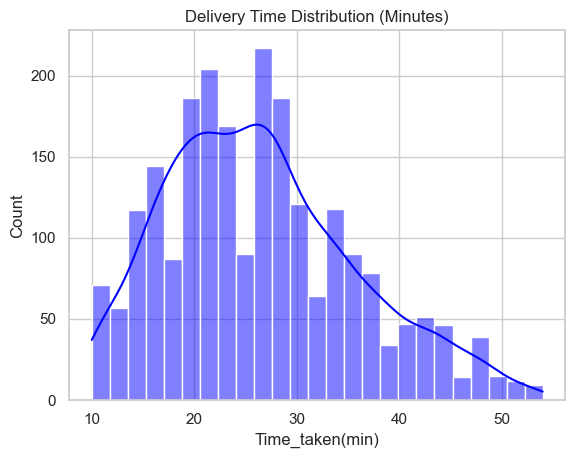

In [117]:
sns.histplot(df_updated['Time_taken(min)'], kde=True, color='blue')
plt.title('Delivery Time Distribution (Minutes)')

- Most deliveries are completed within **15–35 minutes**, peaking around 20–30 minutes.
- The distribution is slightly right-skewed — a portion of deliveries take 40–55 minutes, indicating delayed-delivery cases worth investigating further (traffic, festivals, long distances, etc).

Text(0.5, 1.0, 'Distribution of Distance Traveled (km)')

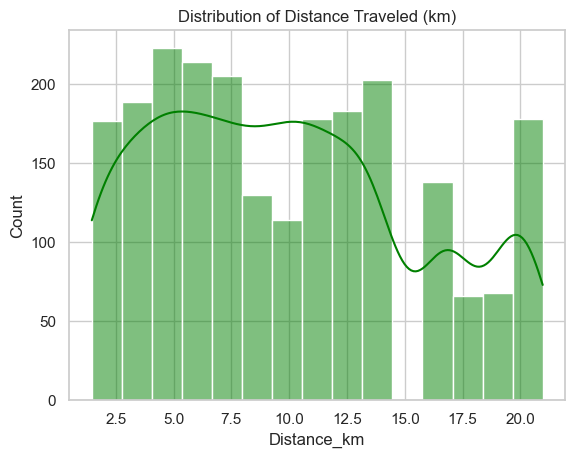

In [118]:
sns.histplot(df_updated['Distance_km'], kde=True, color='green')
plt.title('Distribution of Distance Traveled (km)')

- With the much larger `df_cleaned` sample, the multimodal distance pattern becomes clearer: a main concentration at 2.5–14 km, a gap around 15–16 km, then another cluster at 17–21 km.
- This two-cluster distance pattern (short vs. long) is consistent with the training data findings — reinforcing the idea of two distinct delivery "service zones" with different characteristics.

Text(0.5, 1.0, 'Courier Age Distribution')

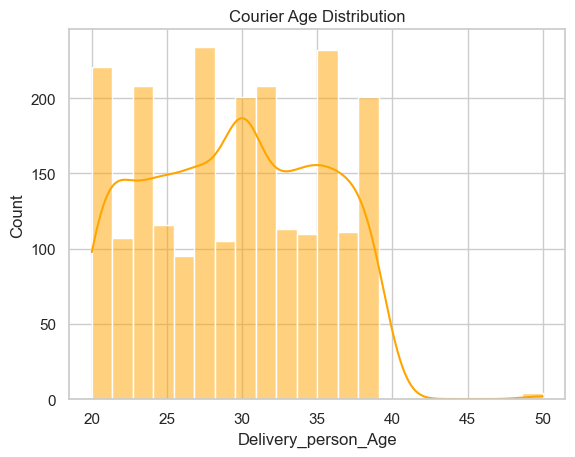

In [119]:
sns.histplot(df_updated['Delivery_person_Age'], kde=True, color='orange')
plt.title('Courier Age Distribution')

- Courier age is concentrated in the **20–39** range, with a multimodal pattern (several local peaks around ages 22, 28, and 35–37) — possibly reflecting different courier recruitment waves.
- Couriers above age 40 are very rare, indicating the courier workforce is dominated by a young, productive-age group.

### Bivariate Analysis

Text(0.5, 1.0, 'Distance (km) vs. Delivery Time (minutes)')

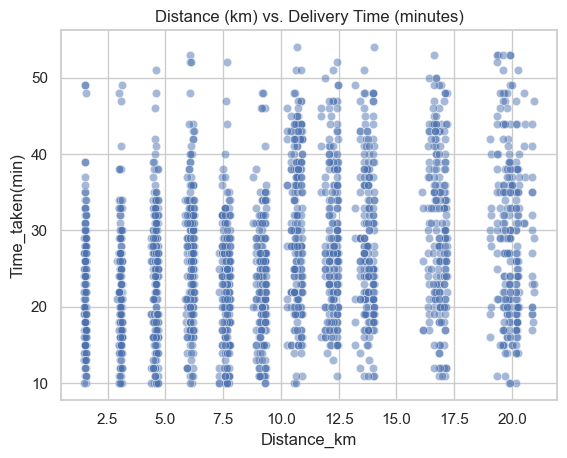

In [120]:
sns.scatterplot(data=df_updated, x='Distance_km', y='Time_taken(min)', alpha=0.5)
plt.title('Distance (km) vs. Delivery Time (minutes)')

- Data points cluster into several distinct distance "bands" rather than a continuous spread, suggesting recorded distances take on a relatively limited/repeated set of values (likely due to a limited variety of location pairs in the dataset).
- At any given distance, delivery time still spans a wide range (10–50+ minutes) — confirming that **distance alone is not a strong single predictor**; other factors such as traffic and multiple deliveries also drive duration.Insight: The scatter plot reveals a positive correlation between distance and delivery time; generally, as the distance increases, the delivery time also tends to increase. However, the relationship is very noisy, with a wide variance in delivery times for any given distance (e.g., a 20 km delivery can take anywhere from 10 to over 50 minutes).   

Implication: Distance alone is not a sufficient predictor of delivery time. Other factors (like traffic, weather, or courier rating) play a massive role in determining the final delivery duration.  

Text(0.5, 1.0, 'Traffic Density vs. Delivery Time')

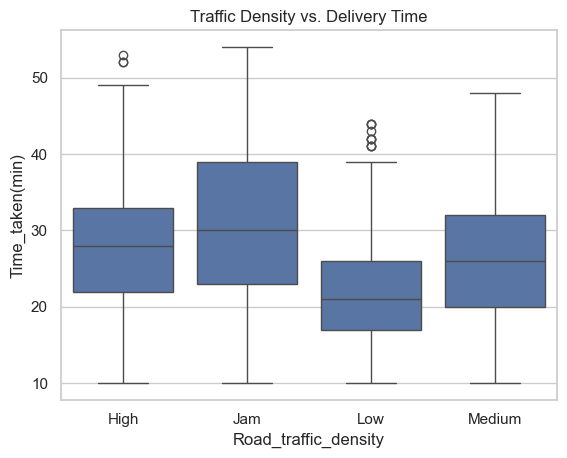

In [121]:
sns.boxplot(data=df_updated, x='Road_traffic_density', y='Time_taken(min)')
plt.title('Traffic Density vs. Delivery Time')

- The **"Jam"** category (heavy congestion) has the highest median delivery time (~30 minutes) and the widest interquartile range (IQR) — the least predictable condition.
- The **"Low"** category has the fastest median (~21 minutes) and the narrowest spread — the most consistent condition.
- The median delivery time order is: Jam > High > Medium > Low, consistent with business intuition and reinforcing why `Road_traffic_density` is the model's most important feature (see point 7).

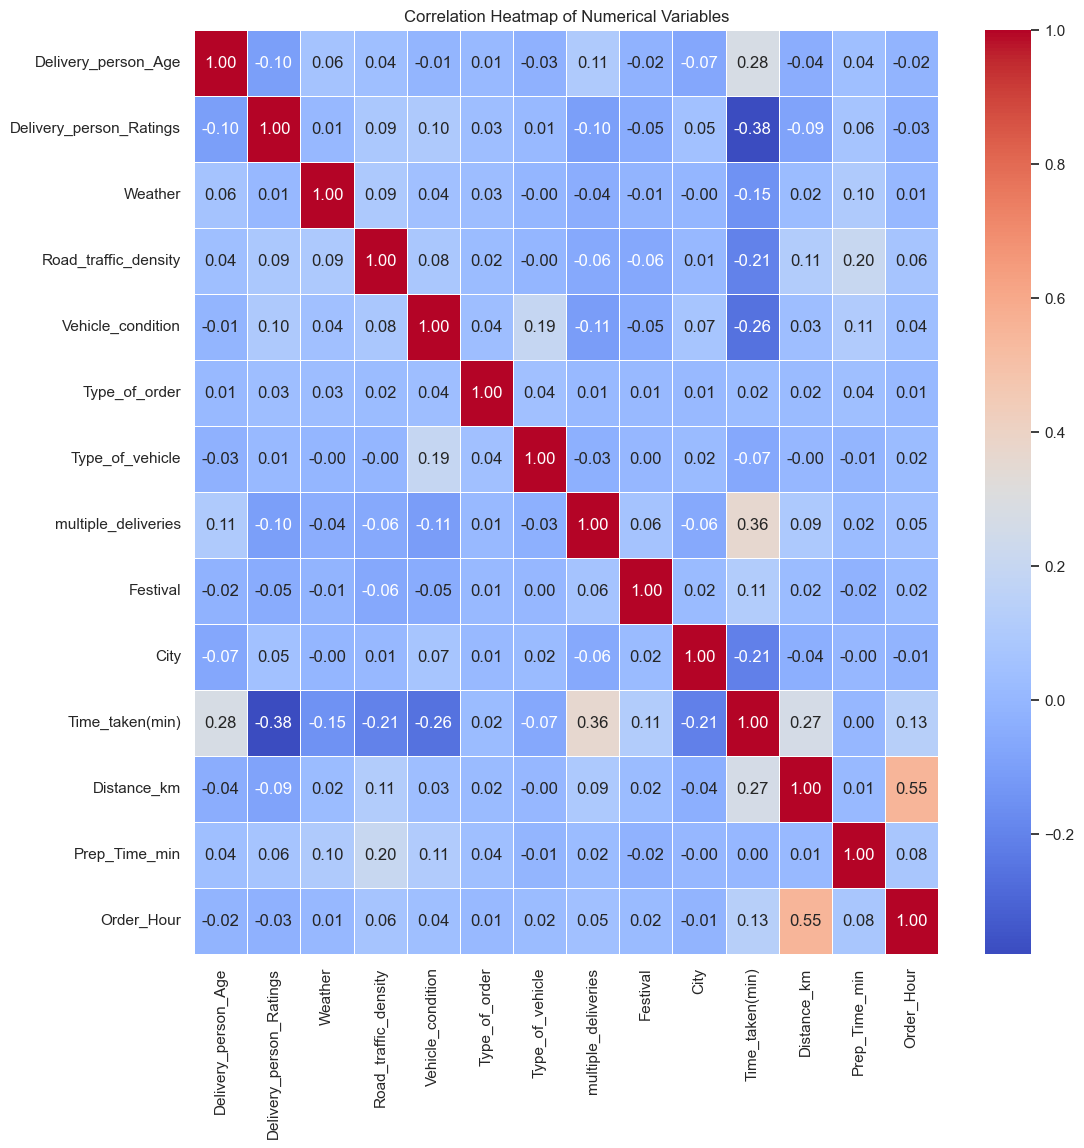

In [122]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

- `Time_taken(min)` correlates most positively with `multiple_deliveries` (**0.36**) and `Delivery_person_Age` (**0.28**), and most negatively with `Delivery_person_Ratings` (**−0.38**) and `Vehicle_condition` (**−0.26**).
- `Road_traffic_density` (−0.21) and `City` (−0.21) also contribute, indicating that traffic context and region meaningfully affect delivery duration.
- A fairly high collinearity was found between `Distance_km` and `Order_Hour` (**0.55**) — certain ordering hours tend to be associated with longer distances, which should be considered when using linear models.
- Most other features (`Type_of_order`, `Prep_Time_min`) show very weak correlation (~0.00–0.02) with the target — suggesting a small individual relationship, though they may still contribute through non-linear interactions (see feature importance).

## **Predictive Analysis**

In [123]:
df.head()

,Delivery_person_Age,Delivery_person_Ratings,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),Distance_km,Prep_Time_min,Order_Hour
0,37,4.9,4,0,2,3,3,0,1,3,24.0,3.025149,15.0,11
1,34,4.5,3,1,2,3,4,1,1,1,33.0,20.183530,5.0,19
2,37,4.4,6,0,0,0,3,2,1,1,42.0,6.210864,5.0,13
3,28,4.9,2,2,1,2,4,1,1,3,19.0,3.073618,15.0,11
4,37,4.6,3,2,0,2,3,1,1,1,25.0,10.564974,10.0,23


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2266 entries, 0 to 2265
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Delivery_person_Age      2266 non-null   int64  
 1   Delivery_person_Ratings  2266 non-null   float64
 2   Weather                  2266 non-null   int64  
 3   Road_traffic_density     2266 non-null   int64  
 4   Vehicle_condition        2266 non-null   int64  
 5   Type_of_order            2266 non-null   int64  
 6   Type_of_vehicle          2266 non-null   int64  
 7   multiple_deliveries      2266 non-null   int64  
 8   Festival                 2266 non-null   int64  
 9   City                     2266 non-null   int64  
 10  Time_taken(min)          2266 non-null   float64
 11  Distance_km              2266 non-null   float64
 12  Prep_Time_min            2266 non-null   float64
 13  Order_Hour               2266 non-null   int32  
dtypes: float64(4), int32(1),

In [125]:
X = df.drop(['Time_taken(min)'], axis=1)
X.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Weather',
       'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
       'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
       'Distance_km', 'Prep_Time_min', 'Order_Hour'],
      dtype='object')

In [126]:
X.shape

(2266, 13)

In [127]:
X = pd.get_dummies(X, columns=['Weather', 'Road_traffic_density', 'Vehicle_condition', 
                               'Type_of_order', 'Type_of_vehicle', 'Festival', 'City', 'multiple_deliveries'])

In [128]:
X

,Delivery_person_Age,Delivery_person_Ratings,Distance_km,Prep_Time_min,Order_Hour,Weather_0,Weather_1,Weather_2,Weather_3,Weather_4,...,Festival_2,Festival_3,City_1,City_2,City_3,City_4,multiple_deliveries_0,multiple_deliveries_1,multiple_deliveries_2,multiple_deliveries_3
0,37,4.9,3.025149,15.0,11,False,False,False,False,True,...,False,False,False,False,True,False,True,False,False,False
1,34,4.5,20.183530,5.0,19,False,False,False,True,False,...,False,False,True,False,False,False,False,True,False,False
2,37,4.4,6.210864,5.0,13,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
3,28,4.9,3.073618,15.0,11,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False
4,37,4.6,10.564974,10.0,23,False,False,False,True,False,...,False,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2261,20,4.7,20.181264,10.0,18,False,False,False,False,True,...,False,False,True,False,False,False,True,False,False,False
2262,32,4.8,19.471476,10.0,22,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
2263,34,5.0,10.906289,15.0,18,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False
2264,37,4.6,4.476871,10.0,17,False,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False


In [129]:
y = df['Time_taken(min)']
y

0       24.0
1       33.0
2       42.0
3       19.0
4       25.0
        ... 
2261    14.0
2262    29.0
2263    22.0
2264    28.0
2265    12.0
Name: Time_taken(min), Length: 2266, dtype: float64

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [131]:
print(len(X_train), len(y_train))
print(len(X_test), len(y_test))

1812 1812
454 454


In [132]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [133]:
X_train_sc, X_test_sc

(array([[ 1.48204998,  0.86328458,  1.722639  , ...,  0.71414284,
         -0.20923384, -0.07065183],
        [-1.68914611, -0.09757025, -1.20467639, ..., -1.40028008,
         -0.20923384, -0.07065183],
        [ 0.42498461,  0.86328458, -0.94432685, ...,  0.71414284,
         -0.20923384, -0.07065183],
        ...,
        [ 0.42498461, -2.98013474,  0.46104503, ...,  0.71414284,
         -0.20923384, -0.07065183],
        [-1.33679099,  0.86328458, -0.09399367, ..., -1.40028008,
         -0.20923384, -0.07065183],
        [ 1.30587242,  0.86328458,  0.10513092, ...,  0.71414284,
         -0.20923384, -0.07065183]]),
 array([[ 1.48204998, -0.09757025, -0.4003823 , ...,  0.71414284,
         -0.20923384, -0.07065183],
        [ 0.77733973, -1.37871002,  0.11545468, ...,  0.71414284,
         -0.20923384, -0.07065183],
        [-1.51296855,  0.54299964,  0.67806021, ..., -1.40028008,
          4.77934151, -0.07065183],
        ...,
        [ 0.07262949,  0.2227147 ,  1.8495793 , ..., -

In [134]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, 
                      colsample_bytree=0.8, random_state=42, tree_method='hist', device='cuda')
model.fit(X_train_sc, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [135]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test_sc)

r2 = r2_score(y_test, y_pred)
print(f"R-squared (R2) Score : {r2*100:.2f}%")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f} minute")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minute")

R-squared (R2) Score : 79.24%
Mean Absolute Error (MAE): 3.34 minute
Root Mean Squared Error (RMSE): 4.29 minute


c:\Anaconda\Lib\site-packages\xgboost\core.py:569: UserWarning: [12:00:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


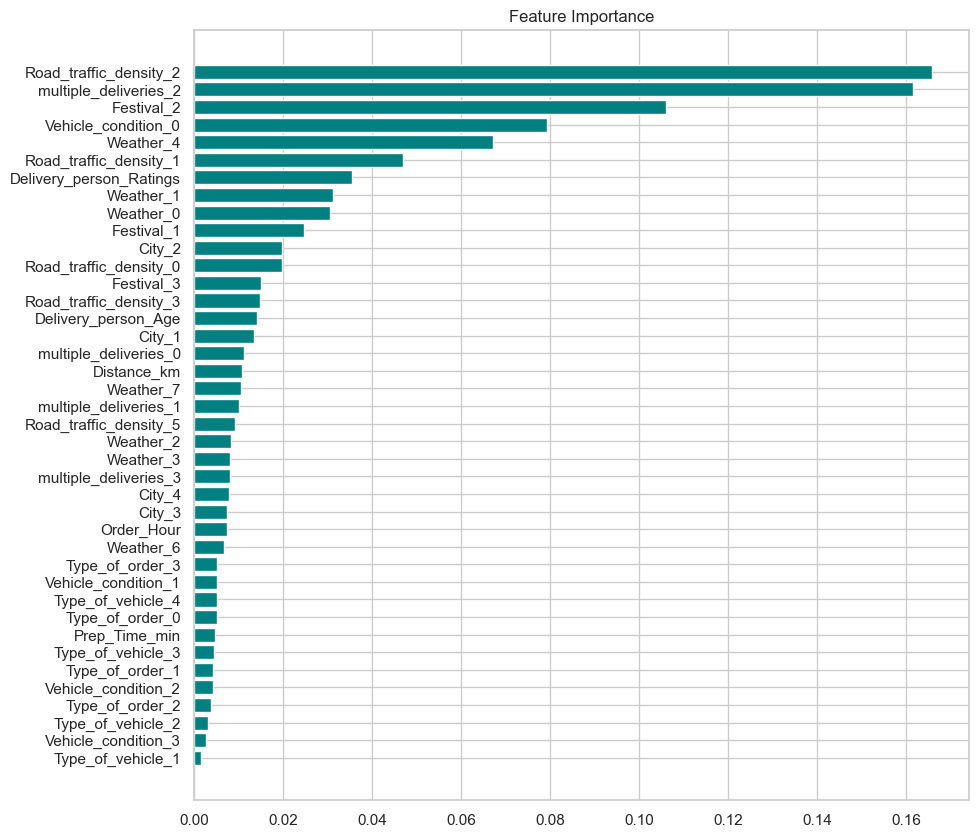

                   Feature  Importance
14  Road_traffic_density_2    0.165809
38   multiple_deliveries_2    0.161396
30              Festival_2    0.105889
17     Vehicle_condition_0    0.079276
9                Weather_4    0.067121


In [136]:
importances = model.feature_importances_

feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 10))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
plt.gca().invert_yaxis() 
plt.title('Feature Importance')
plt.show()

print(feature_importance_df.head())

- The three most influential features for the model's predictions are heavy traffic condition (`Road_traffic_density_2` ≈ 0.166), a specific multiple-delivery load (`multiple_deliveries_2` ≈ 0.161), and festival periods (`Festival_2` ≈ 0.106).
- Interestingly, `Distance_km` and `Delivery_person_Age` — despite showing a noticeable linear correlation in the heatmap — have low importance (<0.02) in the model. This shows XGBoost relies more heavily on **categorical operational conditions** (traffic, festivals, order count) than on numeric distance/age attributes when making split decisions.

In [137]:
X_infer = df_cleaned.drop(columns=['ID', 'Delivery_person_ID', 'Name:'], errors='ignore')

X_infer = pd.get_dummies(
    X_infer,
    columns=['Weather', 'Road_traffic_density', 'Vehicle_condition',
             'Type_of_order', 'Type_of_vehicle', 'Festival', 'City', 'multiple_deliveries']
)

In [138]:
X_infer = X_infer.reindex(columns=X_train.columns, fill_value=0)

In [139]:
df_cleaned['Predicted_Time_taken(min)'] = model.predict(X_infer)

df_cleaned[['ID', 'Predicted_Time_taken(min)']].to_csv(
    './cleaned_data/predicted_test.csv', index=False
)

In [140]:
df_predicted = pd.read_csv('./cleaned_data/predicted_test.csv')

In [141]:
df_predicted

,ID,Predicted_Time_taken(min)
0,0x2318,27.534716
1,0x3474,25.563515
2,0x9420,27.534716
3,0x72ee,25.563515
4,0xa759,27.534716
...,...,...
10524,0x6909,27.534716
10525,0x443b,24.881126
10526,0x1ea5,27.534716
10527,0x22d4,26.152237


Text(0.5, 1.0, 'Distribution Compare Distance_km: Training vs Test')

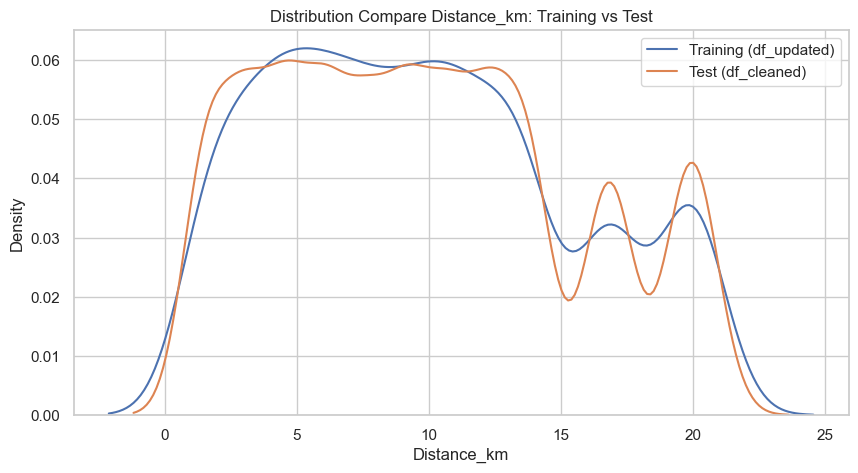

In [142]:
fig, ax = plt.subplots(figsize=(10,5))
sns.kdeplot(df['Distance_km'], label='Training (df_updated)', ax=ax)
sns.kdeplot(df_cleaned['Distance_km'], label='Test (df_cleaned)', ax=ax)
plt.legend()
plt.title('Distribution Compare Distance_km: Training vs Test')

- The shape of the `Distance_km` distribution in the training data (`df_updated`, 2,266 rows) and the test data (`df_cleaned`, 10,529 rows) is **very similar** — both are flat across the 3–13 km range and decline after 15 km.
- This similarity indicates the training data is **fairly representative** of the test set population in terms of distance, so a model trained on `df_updated` is reasonably applicable to `df_cleaned`.

[Text(0.5, 1.0, 'Residual Distribution')]

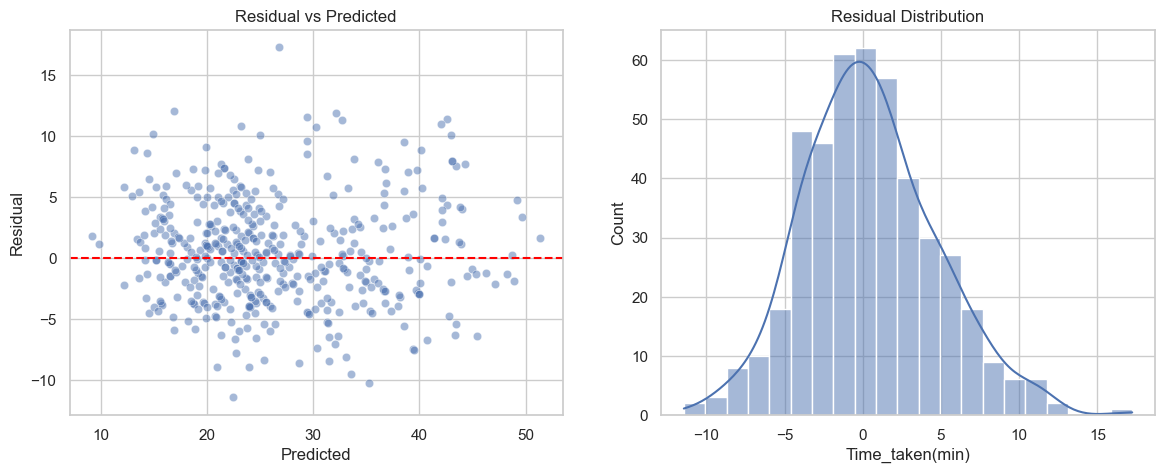

In [143]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set(xlabel='Predicted', ylabel='Residual', title='Residual vs Predicted')

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set(title='Residual Distribution')

- In the *Residual vs Predicted* plot, points are scattered fairly randomly around 0 without forming a clear funnel shape — indicating **no severe heteroscedasticity**; the model is reasonably stable across the range of predicted values.
- The residual distribution is close to normal and centered around 0, though there are a few outlier residuals up to +15–17 minutes — the model occasionally under-predicts significantly for certain cases (likely extreme condition combinations: heavy traffic + festival + multiple deliveries at once), which could be worth further investigation.

## **Data Visualization**

In [144]:
df_actual = df_updated.copy()
df_actual['Data_Source'] = 'Actual (Training)'
df_actual['Time_taken(min)_Final'] = df_actual['Time_taken(min)']

df_pred = df_cleaned.merge(
    df_cleaned[['ID', 'Predicted_Time_taken(min)']], on='ID', how='left'
) if 'Predicted_Time_taken(min)' not in df_cleaned.columns else df_cleaned.copy()

df_pred['Data_Source'] = 'Predicted (Test)'
df_pred['Time_taken(min)_Final'] = df_pred['Predicted_Time_taken(min)']

common_cols = ['ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Weather',
               'Road_traffic_density', 'Vehicle_condition', 'Type_of_order',
               'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City',
               'Distance_km', 'Prep_Time_min', 'Order_Hour',
               'Time_taken(min)_Final', 'Data_Source']

combined = pd.concat([df_actual[common_cols], df_pred[common_cols]], ignore_index=True)
combined['Data_Source'].value_counts()

Data_Source
Predicted (Test)     10529
Actual (Training)     2266
Name: count, dtype: int64

In [145]:
combined

,ID,Delivery_person_Age,Delivery_person_Ratings,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Distance_km,Prep_Time_min,Order_Hour,Time_taken(min)_Final,Data_Source
0,0x4607_x,37.0,4.9,Sunny,High,2,Snack,scooter,0,1,Metropolitian,3.025149,15.0,11,24.000000,Actual (Training)
1,0xb379_x,34.0,4.5,Stormy,Jam,2,Snack,bicycle,1,1,Semi-Urban,20.183530,5.0,19,33.000000,Actual (Training)
2,0x20f7_x,37.0,4.4,Windy,High,0,Buffet,scooter,2,1,Semi-Urban,6.210864,5.0,13,42.000000,Actual (Training)
3,0x7804_x,28.0,4.9,Sandstorms,Low,1,Meal,bicycle,1,1,Metropolitian,3.073618,15.0,11,19.000000,Actual (Training)
4,0x7faf_x,37.0,4.6,Stormy,Low,0,Meal,scooter,1,1,Semi-Urban,10.564974,10.0,23,25.000000,Actual (Training)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12790,0x6909,35.0,4.6,Sunny,Jam,1,Snack,scooter,1,No,Metropolitian,16.384901,10.0,21,27.534716,Predicted (Test)
12791,0x443b,33.0,4.9,Sandstorms,High,1,Drinks,scooter,1,No,Metropolitian,1.489842,5.0,11,24.881126,Predicted (Test)
12792,0x1ea5,30.0,4.7,Sunny,Low,3,Drinks,scooter,1,No,Metropolitian,9.121874,165.0,18,27.534716,Predicted (Test)
12793,0x22d4,27.0,4.7,Sandstorms,Medium,0,Meal,motorcycle,0,No,Metropolitian,19.687777,5.0,18,26.152237,Predicted (Test)


In [146]:
combined['Festival'] = combined['Festival'].replace(1, 'No')

In [147]:
combined.head()

,ID,Delivery_person_Age,Delivery_person_Ratings,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Distance_km,Prep_Time_min,Order_Hour,Time_taken(min)_Final,Data_Source
0,0x4607_x,37.0,4.9,Sunny,High,2,Snack,scooter,0,No,Metropolitian,3.025149,15.0,11,24.0,Actual (Training)
1,0xb379_x,34.0,4.5,Stormy,Jam,2,Snack,bicycle,1,No,Semi-Urban,20.183530,5.0,19,33.0,Actual (Training)
2,0x20f7_x,37.0,4.4,Windy,High,0,Buffet,scooter,2,No,Semi-Urban,6.210864,5.0,13,42.0,Actual (Training)
3,0x7804_x,28.0,4.9,Sandstorms,Low,1,Meal,bicycle,1,No,Metropolitian,3.073618,15.0,11,19.0,Actual (Training)
4,0x7faf_x,37.0,4.6,Stormy,Low,0,Meal,scooter,1,No,Semi-Urban,10.564974,10.0,23,25.0,Actual (Training)


In [148]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12795 entries, 0 to 12794
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       12795 non-null  object 
 1   Delivery_person_Age      12795 non-null  float64
 2   Delivery_person_Ratings  12795 non-null  float64
 3   Weather                  12795 non-null  object 
 4   Road_traffic_density     12795 non-null  object 
 5   Vehicle_condition        12795 non-null  int64  
 6   Type_of_order            12795 non-null  object 
 7   Type_of_vehicle          12795 non-null  object 
 8   multiple_deliveries      12795 non-null  int64  
 9   Festival                 12795 non-null  object 
 10  City                     12795 non-null  object 
 11  Distance_km              12795 non-null  float64
 12  Prep_Time_min            12795 non-null  float64
 13  Order_Hour               12795 non-null  int32  
 14  Time_taken(min)_Final 

In [150]:
combined['Weather'].value_counts()

Weather
Sunny         2337
Windy         2162
Sandstorms    2128
Cloudy        2123
Stormy        2048
Fog           1997
Name: count, dtype: int64

In [151]:
combined['Road_traffic_density'].value_counts()

Road_traffic_density
Low       4504
Jam       3971
Medium    3062
High      1258
Name: count, dtype: int64

In [152]:
combined['City'].value_counts()

City
Metropolitian    8737
Urban            2340
Semi-Urban       1718
Name: count, dtype: int64

In [153]:
combined.to_csv('./cleaned_data/combined_data.csv', index=False)

In [154]:
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
feat_imp.to_csv('./cleaned_data/feature_importance.csv', index=False)

In [155]:
corr_matrix = df.corr().reset_index().rename(columns={'index':'Feature'})
corr_matrix.to_csv('./cleaned_data/correlation_matrix.csv', index=False)